# DATASET PREPROCESSING

In [9]:
import os, yaml, shutil
from PIL import Image
from collections import Counter
import random


DS1 = "/kaggle/input/datasets/vinaymarrey/helmet-detection/helmet-detection-and-license-plate-recognition.v1i.yolov8"
DS2 = "/kaggle/input/datasets/santoshvishwakarma99/indian-license-plate-dataset/dataset"


DS1_OUT = "/kaggle/working/ds1"
DS2_OUT = "/kaggle/working/ds2"

os.makedirs(DS1_OUT, exist_ok=True)
os.makedirs(DS2_OUT, exist_ok=True)

print("✅ Paths set successfully!")
print(f"DS1 source : {DS1}")
print(f"DS2 source : {DS2}")
print(f"DS1 output : {DS1_OUT}")
print(f"DS2 output : {DS2_OUT}")

✅ Paths set successfully!
DS1 source : /kaggle/input/datasets/vinaymarrey/helmet-detection/helmet-detection-and-license-plate-recognition.v1i.yolov8
DS2 source : /kaggle/input/datasets/santoshvishwakarma99/indian-license-plate-dataset/dataset
DS1 output : /kaggle/working/ds1
DS2 output : /kaggle/working/ds2


In [10]:
# Read original yaml
yaml_path = os.path.join(DS1, "data.yaml")

with open(yaml_path, 'r') as f:
    data = yaml.safe_load(f)

print("BEFORE fix:")
print("  Classes:", data['names'])
print("  NC     :", data['nc'])

# Rename classes to match YOUR project
# Original: ['helmet', 'licenseplate', 'motorcyclist', 'nohelmet']
# Renamed:  ['helmet', 'number_plate', 'rider', 'no_helmet']
data['names'] = ['helmet', 'number_plate', 'rider', 'no_helmet']
data['nc'] = 4

# Fix paths to point to working directory
data['train'] = '/kaggle/working/ds1/train/images'
data['val']   = '/kaggle/working/ds1/valid/images'
data['test']  = '/kaggle/working/ds1/test/images'

# Save updated yaml to working directory
out_yaml = os.path.join(DS1_OUT, "data.yaml")
with open(out_yaml, 'w') as f:
    yaml.dump(data, f)

print("\nAFTER fix:")
print("  Classes:", data['names'])
print("  Train  :", data['train'])
print("  Val    :", data['val'])
print("✅ data.yaml updated!")

BEFORE fix:
  Classes: ['helmet', 'licenseplate', 'motorcyclist', 'nohelmet']
  NC     : 4

AFTER fix:
  Classes: ['helmet', 'number_plate', 'rider', 'no_helmet']
  Train  : /kaggle/working/ds1/train/images
  Val    : /kaggle/working/ds1/valid/images
✅ data.yaml updated!


In [11]:
# Copy DS1 folders to /kaggle/working/ds1
print("Copying DS1 to working directory...")

for split in ['train', 'valid', 'test']:
    src = os.path.join(DS1, split)
    dst = os.path.join(DS1_OUT, split)
    
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        
        img_count = len(os.listdir(os.path.join(dst, 'images')))
        lbl_count = len(os.listdir(os.path.join(dst, 'labels')))
        print(f"  ✅ {split}: {img_count} images | {lbl_count} labels")
    else:
        print(f"  ⚠️ {split} folder not found")

print("\n✅ DS1 copied successfully!")

Copying DS1 to working directory...
  ✅ train: 5248 images | 5248 labels
  ✅ valid: 984 images | 984 labels
  ✅ test: 330 images | 330 labels

✅ DS1 copied successfully!


In [12]:
# Check 5 random label files
import random

label_dir = os.path.join(DS1_OUT, "train/labels")
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
class_names = ['helmet', 'number_plate', 'rider', 'no_helmet']

print("=== Sample Label Check ===")
for fname in random.sample(label_files, 5):
    fpath = os.path.join(label_dir, fname)
    with open(fpath, 'r') as f:
        lines = f.readlines()
    print(f"\n📄 {fname}:")
    for line in lines:
        parts = line.strip().split()
        cid = int(parts[0])
        print(f"   class {cid} = {class_names[cid]}")

=== Sample Label Check ===

📄 Without_Helmet-934-_jpg.rf.3b8d932c6fcd6d0cc911f593f4a3cf82.txt:
   class 3 = no_helmet
   class 3 = no_helmet
   class 3 = no_helmet

📄 2023_09_20_15_28_IMG_5804_MOV-2_jpg.rf.60d93142ce06720602591cd6099710cd.txt:
   class 2 = rider
   class 0 = helmet
   class 1 = number_plate

📄 Without_Helmet-958-_jpg.rf.fa2028c91df629b74844181c41aed3a4.txt:
   class 3 = no_helmet

📄 2023_09_28_17_32_IMG_5814_MOV-19_jpg.rf.e87664651e4703a1b230ff952bc990b3.txt:
   class 2 = rider
   class 3 = no_helmet
   class 1 = number_plate

📄 2023_09_20_15_23_IMG_5800_MOV-56_jpg.rf.bec62986ddd5ffe68261458f6fe737bd.txt:
   class 2 = rider
   class 1 = number_plate
   class 0 = helmet
   class 2 = rider
   class 3 = no_helmet
   class 1 = number_plate


In [13]:
# Count annotations per class in train set
counts = Counter()
label_dir = os.path.join(DS1_OUT, "train/labels")

for fname in os.listdir(label_dir):
    if not fname.endswith('.txt'):
        continue
    with open(os.path.join(label_dir, fname), 'r') as f:
        for line in f:
            cid = int(line.strip().split()[0])
            counts[class_names[cid]] += 1

print("=== DS1 Class Distribution (Train) ===")
total = sum(counts.values())
for cls in class_names:
    count = counts.get(cls, 0)
    bar = '█' * (count // 500)
    print(f"  {cls:15s}: {count:6,}  {bar}")
print(f"\n  Total annotations: {total:,}")

=== DS1 Class Distribution (Train) ===
  helmet         :  3,731  ███████
  number_plate   :  4,138  ████████
  rider          :  4,285  ████████
  no_helmet      :  5,564  ███████████

  Total annotations: 17,718


In [14]:
# Copy DS2 to working directory
print("Copying DS2 to working directory...")

shutil.copytree(DS2, DS2_OUT, dirs_exist_ok=True)

print("\n=== DS2 Final Structure ===")
for split in ['train', 'val']:
    for cls in ['hsrp', 'non-hsrp']:
        path = os.path.join(DS2_OUT, split, cls)
        if os.path.exists(path):
            count = len(os.listdir(path))
            print(f"  ✅ {split}/{cls}: {count} images")

print("\n✅ DS2 ready!")

Copying DS2 to working directory...

=== DS2 Final Structure ===
  ✅ train/hsrp: 400 images
  ✅ train/non-hsrp: 400 images
  ✅ val/hsrp: 100 images
  ✅ val/non-hsrp: 100 images

✅ DS2 ready!


In [15]:
import os
import shutil

# Define where the images currently are and where they should go
splits_mapping = {
    'train': 'train',
    'val': 'valid'
}

# Mapping subfolders to new, non-overlapping YOLO class IDs
class_mapping = {
    'hsrp': 4,       # class 4 = HSRP plate
    'non-hsrp': 5    # class 5 = Non-HSRP plate
}

print("⚙️ Processing and merging DS2 into DS1 directory...")

for ds2_split, ds1_split in splits_mapping.items():
    for cls_folder, new_class_id in class_mapping.items():
        src_img_dir = os.path.join(DS2_OUT, ds2_split, cls_folder)
        dst_img_dir = os.path.join(DS1_OUT, ds1_split, 'images')
        dst_lbl_dir = os.path.join(DS1_OUT, ds1_split, 'labels')
        
        if not os.path.exists(src_img_dir):
            continue
            
        for img_name in os.listdir(src_img_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
                
            # 1. Copy the image over to the main YOLO training directory
            src_img_path = os.path.join(src_img_dir, img_name)
            dst_img_path = os.path.join(dst_img_dir, f"ds2_{img_name}")
            shutil.copy(src_img_path, dst_img_path)
            
            # 2. Automatically generate the bounding box covering the full crop area
            base_name = os.path.splitext(img_name)[0]
            lbl_name = f"ds2_{base_name}.txt"
            lbl_path = os.path.join(dst_lbl_dir, lbl_name)
            
            # Writes standard full-image bounding box (Class_ID Center_X Center_Y Width Height)
            with open(lbl_path, 'w') as f:
                f.write(f"{new_class_id} 0.5 0.5 1.0 1.0\n")

print("✅ DS2 successfully converted and combined with DS1!")

⚙️ Processing and merging DS2 into DS1 directory...
✅ DS2 successfully converted and combined with DS1!


In [16]:
print("=" * 45)
print("   PREPROCESSING COMPLETE ✅")
print("=" * 45)

# DS1 summary
for split in ['train', 'valid', 'test']:
    path = os.path.join(DS1_OUT, split, 'images')
    count = len(os.listdir(path)) if os.path.exists(path) else 0
    print(f"DS1 {split:6s}: {count} images")

print()

# DS2 summary
for split in ['train', 'val']:
    for cls in ['hsrp', 'non-hsrp']:
        path = os.path.join(DS2_OUT, split, cls)
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"DS2 {split}/{cls}: {count} images")

print()
print(f"data.yaml : /kaggle/working/ds1/data.yaml ✅")
print("Ready for training! 🚀")

   PREPROCESSING COMPLETE ✅
DS1 train : 6046 images
DS1 valid : 1184 images
DS1 test  : 330 images

DS2 train/hsrp: 400 images
DS2 train/non-hsrp: 400 images
DS2 val/hsrp: 100 images
DS2 val/non-hsrp: 100 images

data.yaml : /kaggle/working/ds1/data.yaml ✅
Ready for training! 🚀


# DATA TRAINING

In [2]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.61 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.3/8062.4 GB disk)


In [ ]:
import yaml

with open("/kaggle/working/ds1/data.yaml", 'r') as f:
    data = yaml.safe_load(f)

print("Classes :", data['names'])
print("NC      :", data['nc'])
print("Train   :", data['train'])
print("Val     :", data['val'])
print("Test    :", data['test'])
print("\n✅ data.yaml looks good!")

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train
results = model.train(
    data    = '/kaggle/working/ds1/data.yaml',
    epochs  = 30,
    imgsz   = 640,
    batch   = 16,
    name    = 'helmet_violation_v1',
    project = '/kaggle/working/runs',
    device  = 0,            
    patience= 10,            
    save    = True,
    plots   = True,
    verbose = True
)

print("\n✅ Training complete!")

In [ ]:
from ultralytics import YOLO
import os

# Load your trained model
model = YOLO("/kaggle/working/runs/helmet_violation_v1-2/weights/best.pt")

# ✅ Check 1: Model info
print("=== Model Info ===")
print(f"Classes : {model.names}")
print(f"NC      : {len(model.names)}")

# ✅ Check 2: Weights file exists
weights = "/kaggle/working/runs/helmet_violation_v1-2/weights/best.pt"
size = os.path.getsize(weights) / (1024*1024)
print(f"\n=== Weights ===")
print(f"best.pt : {size:.1f} MB ✅")

# ✅ Check 3: Test on one real image
test_dir = "/kaggle/working/ds1/test/images"
test_img = os.path.join(test_dir, os.listdir(test_dir)[0])

print(f"\n=== Running inference on test image ===")
print(f"Image: {os.path.basename(test_img)}")

results = model(test_img, conf=0.25)

print("\nDetections found:")
if len(results[0].boxes) == 0:
    print("  ⚠️ No detections — try lower conf threshold")
else:
    for box in results[0].boxes:
        cls  = int(box.cls)
        conf = float(box.conf)
        print(f"  ✅ {model.names[cls]:15s} : {conf:.2f}")

In [ ]:
import matplotlib.pyplot as plt

# Plot result
result_img = results[0].plot()

plt.figure(figsize=(12, 8))
plt.imshow(result_img[:, :, ::-1])
plt.axis('off')
plt.title("Detection Result — 3 epoch model")
plt.show()

In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
import easyocr
import os

# Load your trained model
model = YOLO("/kaggle/input/datasets/vinaymarrey/hellohhh/best.pt")
print("✅ YOLO model loaded!")
print(f"Classes: {model.names}")

✅ YOLO model loaded!
Classes: {0: 'helmet', 1: 'number_plate', 2: 'rider', 3: 'no_helmet'}


In [4]:
# Initialize EasyOCR
reader = easyocr.Reader(['en'], gpu=True)
print("✅ EasyOCR ready!")

✅ EasyOCR ready!


In [5]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# Build MobileNetV2 classifier
def build_hsrp_classifier():
    model = models.mobilenet_v2(pretrained=True)
    model.classifier[1] = nn.Linear(1280, 2)  # 2 classes: hsrp, non-hsrp
    return model

# Transform for classifier input
hsrp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

hsrp_classes = ['hsrp', 'non-hsrp']

# NOTE: This uses pretrained weights for now
# After training Model 2, replace with:
# hsrp_model.load_state_dict(torch.load("hsrp_model.pth"))
hsrp_model = build_hsrp_classifier()
hsrp_model.eval()
print("✅ HSRP classifier ready (pretrained base)!")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]

✅ HSRP classifier ready (pretrained base)!


In [6]:
def run_rule_engine(detections):
    """
    Input:  list of detections from YOLO
    Output: violations dict with severity
    """
    violations    = []
    severity      = "NONE"

    helmet_count    = 0
    no_helmet_count = 0
    rider_count     = 0
    plate_found     = False

    for det in detections:
        cls = det['class']
        if cls == 'helmet'      : helmet_count    += 1
        if cls == 'no_helmet'   : no_helmet_count += 1
        if cls == 'rider'       : rider_count     += 1
        if cls == 'number_plate': plate_found      = True

    # Rule 1: No helmet
    if no_helmet_count > 0:
        violations.append("NO HELMET")

    # Rule 2: Triple riding — proximity based (fixes false positives)
    def check_triple_riding(detections, proximity=150):
        riders = [d['bbox'] for d in detections if d['class'] == 'rider']

        if len(riders) < 3:
            return False

        for i in range(len(riders)):
            nearby = 0
            rx = (riders[i][0] + riders[i][2]) / 2
            ry = (riders[i][1] + riders[i][3]) / 2

            for j in range(len(riders)):
                if i == j: continue
                ox = (riders[j][0] + riders[j][2]) / 2
                oy = (riders[j][1] + riders[j][3]) / 2
                dist = ((rx-ox)**2 + (ry-oy)**2) ** 0.5
                if dist < proximity:
                    nearby += 1

            if nearby >= 2:
                return True
        return False

    if check_triple_riding(detections):
        violations.append("TRIPLE RIDING")

    # Rule 3: Severity
    if len(violations) == 0:
        severity = "NONE"
    elif "TRIPLE RIDING" in violations and "NO HELMET" in violations:
        severity = "HIGH"
    elif "TRIPLE RIDING" in violations:
        severity = "MEDIUM"
    elif "NO HELMET" in violations:
        severity = "LOW"

    return {
        "violations"     : violations,
        "severity"       : severity,
        "helmet_count"   : helmet_count,
        "no_helmet_count": no_helmet_count,
        "rider_count"    : rider_count,
        "plate_found"    : plate_found
    }

print("✅ Rule engine ready!")

✅ Rule engine ready!


In [7]:
def run_full_pipeline(image_path, conf_threshold=0.25):
    """
    Complete pipeline:
    Image → YOLO → OCR → HSRP → Rule Engine → Final Output
    """
    print(f"\n{'='*50}")
    print(f"Processing: {os.path.basename(image_path)}")
    print(f"{'='*50}")

    # Read image
    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── STEP 1: YOLO Detection ──────────────────────
    results    = model(image_path, conf=conf_threshold, verbose=False)
    boxes      = results[0].boxes
    detections = []
    plate_crop = None

    for box in boxes:
        cls_id   = int(box.cls)
        conf     = float(box.conf)
        cls_name = model.names[cls_id]
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        detections.append({
            'class': cls_name,
            'conf' : conf,
            'bbox' : (x1, y1, x2, y2)
        })

        # Crop plate for OCR + HSRP — tighter crop
        if cls_name == 'number_plate':
            height   = y2 - y1
            width    = x2 - x1
            y1_tight = y1 + int(height * 0.6)
            x1_tight = x1 + int(width  * 0.1)
            x2_tight = x2 - int(width  * 0.1)
            plate_crop = img_rgb[y1_tight:y2, x1_tight:x2_tight]

    print(f"\n📦 YOLO Detections ({len(detections)} found):")
    for d in detections:
        print(f"   {d['class']:15s} → conf: {d['conf']:.2f}")

    # ── STEP 2: OCR on plate ────────────────────────
    plate_number = "NOT FOUND"
    if plate_crop is not None and plate_crop.size > 0:
        ocr_results  = reader.readtext(plate_crop)
        if ocr_results:
            plate_number = max(ocr_results, key=lambda x: x[2])[1]
            plate_number = plate_number.upper().replace(" ", "")
        print(f"\n🔤 OCR Result: {plate_number}")
    else:
        print(f"\n🔤 OCR: No plate detected")

    # ── STEP 3: HSRP Classification ─────────────────
    hsrp_status = "UNKNOWN"
    if plate_crop is not None and plate_crop.size > 0:
        try:
            pil_img    = Image.fromarray(plate_crop)
            tensor     = hsrp_transform(pil_img).unsqueeze(0)
            with torch.no_grad():
                output = hsrp_model(tensor)
                pred   = torch.argmax(output, dim=1).item()
            hsrp_status = hsrp_classes[pred]
        except:
            hsrp_status = "UNKNOWN"
        print(f"🪪  HSRP Status: {hsrp_status}")
    else:
        print(f"🪪  HSRP: No plate to classify")

    # ── STEP 4: Rule Engine ─────────────────────────
    rule_result = run_rule_engine(detections)

    print(f"\n⚖️  Rule Engine Results:")
    print(f"   Riders found     : {rule_result['rider_count']}")
    print(f"   Helmet           : {rule_result['helmet_count']}")
    print(f"   No Helmet        : {rule_result['no_helmet_count']}")
    print(f"   Violations       : {rule_result['violations']}")
    print(f"   Severity         : {rule_result['severity']}")

    # ── STEP 5: Final Output ────────────────────────
    final_output = {
        "plate_number" : plate_number,
        "hsrp_status"  : hsrp_status,
        "helmet_status": "VIOLATION" if rule_result['no_helmet_count'] > 0 else "OK",
        "triple_riding": "VIOLATION" if rule_result['rider_count'] >= 3 else "OK",
        "violations"   : rule_result['violations'],
        "severity"     : rule_result['severity']
    }

    print(f"\n{'='*50}")
    print(f"   FINAL OUTPUT")
    print(f"{'='*50}")
    print(f"   🪖  Helmet Status : {final_output['helmet_status']}")
    print(f"   👥  Triple Riding : {final_output['triple_riding']}")
    print(f"   🪪  HSRP Status   : {final_output['hsrp_status']}")
    print(f"   🔤  Plate Number  : {final_output['plate_number']}")
    print(f"   ⚠️  Violations    : {final_output['violations']}")
    print(f"   🚨  Severity      : {final_output['severity']}")
    print(f"{'='*50}")

    return final_output, results

print("✅ Pipeline function ready!")

✅ Pipeline function ready!



Processing: 337_png_jpg.rf.6b21356da3f524e5596ec3c202e9b6d7.jpg

📦 YOLO Detections (1 found):
   no_helmet       → conf: 0.74

🔤 OCR: No plate detected
🪪  HSRP: No plate to classify

⚖️  Rule Engine Results:
   Riders found     : 0
   Helmet           : 0
   No Helmet        : 1
   Violations       : ['NO HELMET']
   Severity         : LOW

   FINAL OUTPUT
   🪖  Helmet Status : VIOLATION
   👥  Triple Riding : OK
   🪪  HSRP Status   : UNKNOWN
   🔤  Plate Number  : NOT FOUND
   ⚠️  Violations    : ['NO HELMET']
   🚨  Severity      : LOW


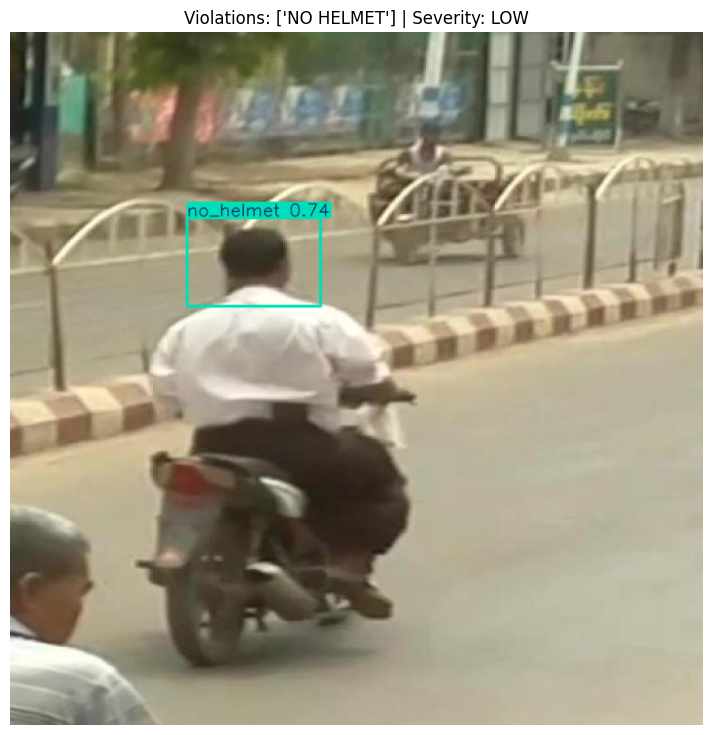

In [17]:
import matplotlib.pyplot as plt

# Pick a test image
test_dir = "/kaggle/working/ds1/test/images"
test_img = os.path.join(test_dir, os.listdir(test_dir)[212])

# Run full pipeline
output, yolo_results = run_full_pipeline(test_img, conf_threshold=0.25)

# Show annotated image
result_img = yolo_results[0].plot()
plt.figure(figsize=(14, 9))
plt.imshow(result_img[:, :, ::-1])
plt.axis('off')
plt.title(f"Violations: {output['violations']} | Severity: {output['severity']}")
plt.show()


Processing: 249_png_jpg.rf.2e7f1eb5b005ba4924af36616f2e625e.jpg

📦 YOLO Detections (1 found):
   no_helmet       → conf: 0.73

🔤 OCR: No plate detected
🪪  HSRP: No plate to classify

⚖️  Rule Engine Results:
   Riders found     : 0
   Helmet           : 0
   No Helmet        : 1
   Violations       : ['NO HELMET']
   Severity         : LOW

   FINAL OUTPUT
   🪖  Helmet Status : VIOLATION
   👥  Triple Riding : OK
   🪪  HSRP Status   : UNKNOWN
   🔤  Plate Number  : NOT FOUND
   ⚠️  Violations    : ['NO HELMET']
   🚨  Severity      : LOW


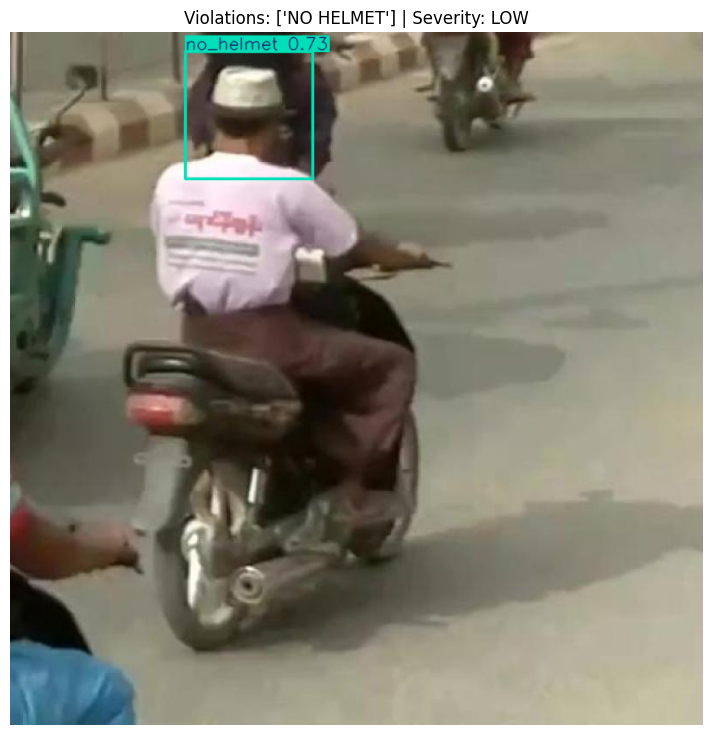

In [18]:
import matplotlib.pyplot as plt

# Pick a test image
test_dir = "/kaggle/working/ds1/test/images"
test_img = os.path.join(test_dir, os.listdir(test_dir)[200])

# Run full pipeline
output, yolo_results = run_full_pipeline(test_img, conf_threshold=0.25)

# Show annotated image
result_img = yolo_results[0].plot()
plt.figure(figsize=(14, 9))
plt.imshow(result_img[:, :, ::-1])
plt.axis('off')
plt.title(f"Violations: {output['violations']} | Severity: {output['severity']}")
plt.show()